# 1. For Diagonal Co-Variance matrix

Classifier Accuracy: 62.81%


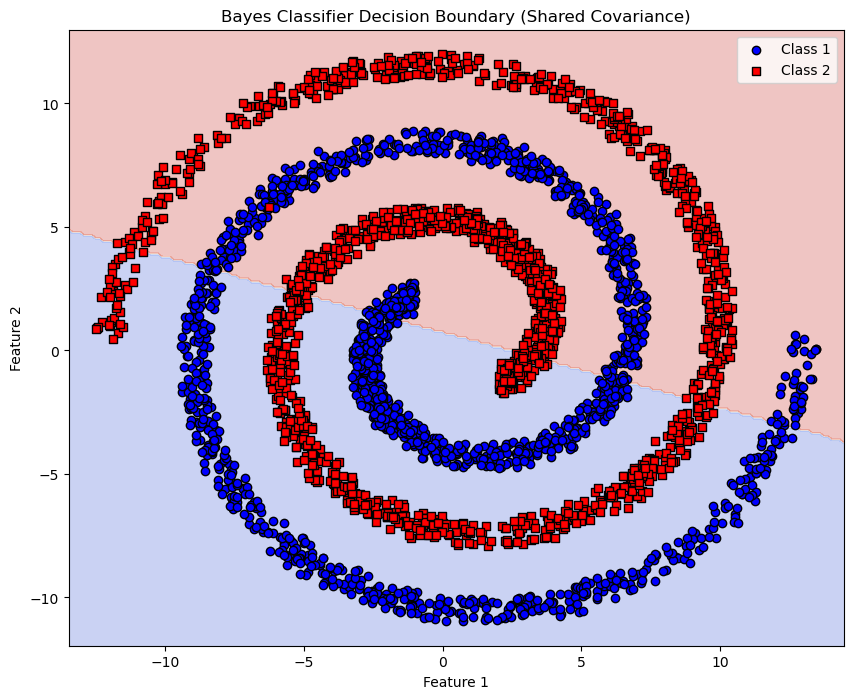

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the files
class1_data = np.loadtxt('NSL_Group03/class1.txt')
class2_data = np.loadtxt('NSL_Group03/class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covariances[c] = np.cov(X_c, rowvar=False)
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Calculate the average covariance matrix (for shared covariance assumption)
average_covariance = np.mean(list(covariances.values()), axis=0)
# Convert the full covariance to diagonal covariance (σ^2 * I)
average_variance = np.mean(np.diag(average_covariance))
shared_covariance = average_variance * np.eye(X_train.shape[1])

# Define function to calculate multivariate Gaussian PDF
def multivariate_gaussian_pdf(x, mean, cov):
    size = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = 1.0 / (np.power((2 * np.pi), float(size) / 2) * np.sqrt(det_cov))
    x_mu = np.matrix(x - mean)
    result = np.exp(-0.5 * (x_mu * inv_cov * x_mu.T))
    return norm_const * result

# Define the Bayes classifier manually
def bayes_classifier(X, means, shared_cov, priors):
    y_pred = []
    for x in X:
        posteriors = []
        for c in means.keys():
            prior = np.log(priors[c])
            likelihood = np.log(multivariate_gaussian_pdf(x, means[c], shared_cov))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(np.argmax(posteriors))
    return np.array(y_pred)

# Define the priors (assuming equal priors for simplicity)
priors = {0: 0.5, 1: 0.5}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, shared_covariance, priors)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the grid
Z = bayes_classifier(grid, means, shared_covariance, priors)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Bayes Classifier Decision Boundary (Shared Covariance)')
plt.legend()
plt.show()


# 2. For Full Co-Variance matrix

Classifier Accuracy: 62.60%


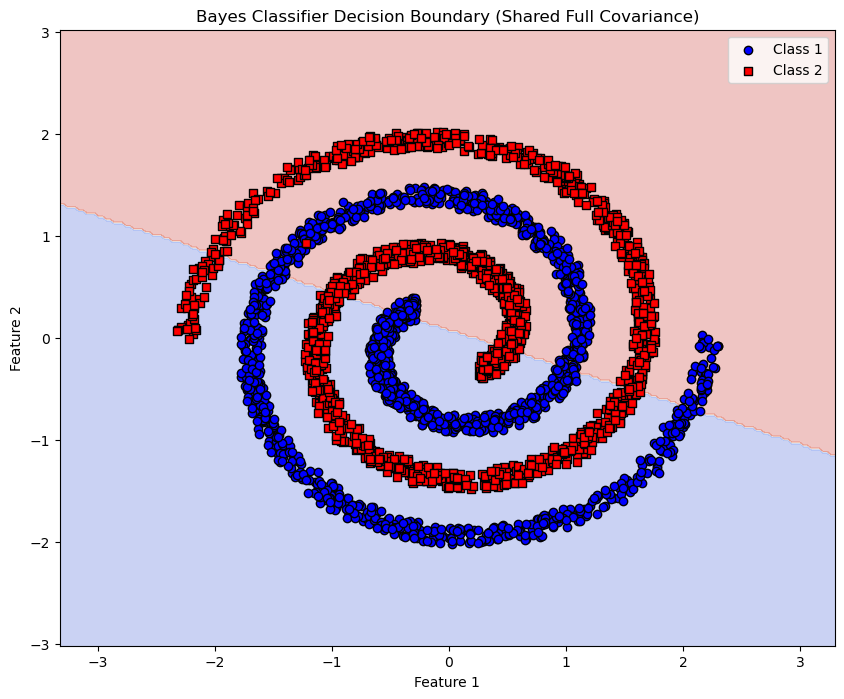

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the files, skipping the header row
class1_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class1.txt')
class2_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Feature scaling (Standardization)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covariances[c] = np.cov(X_c, rowvar=False)
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Calculate the average covariance matrix (for shared covariance assumption)
shared_covariance = np.mean(list(covariances.values()), axis=0)

# Define function to calculate multivariate Gaussian PDF
def multivariate_gaussian_pdf(x, mean, cov):
    size = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = 1.0 / (np.power((2 * np.pi), float(size) / 2) * np.sqrt(det_cov))
    x_mu = np.matrix(x - mean)
    result = np.exp(-0.5 * (x_mu * inv_cov * x_mu.T))
    return norm_const * result

# Define the Bayes classifier manually
def bayes_classifier(X, means, shared_cov, priors):
    y_pred = []
    for x in X:
        posteriors = []
        for c in means.keys():
            prior = np.log(priors[c])
            likelihood = np.log(multivariate_gaussian_pdf(x, means[c], shared_cov))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(np.argmax(posteriors))
    return np.array(y_pred)

# Calculate priors based on training data
class_counts = np.bincount(y_train)
priors = {0: class_counts[0] / len(y_train), 1: class_counts[1] / len(y_train)}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, shared_covariance, priors)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the grid
Z = bayes_classifier(grid, means, shared_covariance, priors)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Bayes Classifier Decision Boundary (Shared Full Covariance)')
plt.legend()
plt.show()


# 3. for Diaogonal Co-variance Matrix & having different for each classes : 

Classifier Accuracy: 62.74%


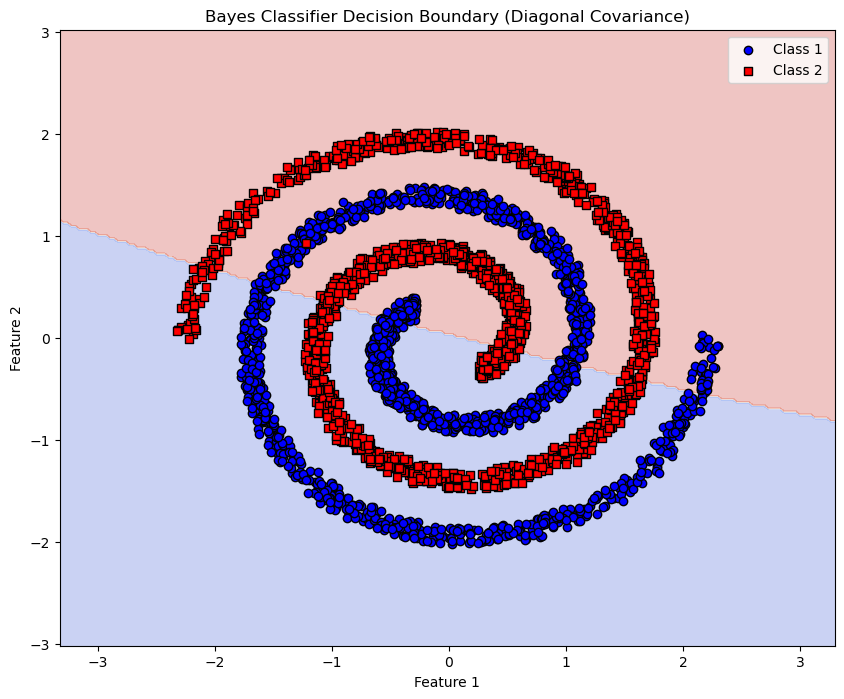

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the files, skipping the header row
class1_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class1.txt')
class2_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Feature scaling (Standardization)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and diagonal covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        full_covariance = np.cov(X_c, rowvar=False)
        covariances[c] = np.diag(np.diag(full_covariance))  # Keep only the diagonal elements
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Define function to calculate multivariate Gaussian PDF for diagonal covariance
def multivariate_gaussian_pdf_diagonal(x, mean, diag_cov):
    size = len(x)
    norm_const = 1.0 / np.sqrt((2 * np.pi) ** size * np.prod(np.diag(diag_cov)))
    x_mu = x - mean
    result = np.exp(-0.5 * np.sum((x_mu ** 2) / np.diag(diag_cov)))
    return norm_const * result

# Define the Bayes classifier manually
def bayes_classifier(X, means, covariances, priors):
    y_pred = []
    for x in X:
        posteriors = []
        for c in means.keys():
            prior = np.log(priors[c])
            likelihood = np.log(multivariate_gaussian_pdf_diagonal(x, means[c], covariances[c]))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(np.argmax(posteriors))
    return np.array(y_pred)

# Calculate priors based on training data
class_counts = np.bincount(y_train)
priors = {0: class_counts[0] / len(y_train), 1: class_counts[1] / len(y_train)}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, covariances, priors)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the grid
Z = bayes_classifier(grid, means, covariances, priors)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Bayes Classifier Decision Boundary (Diagonal Covariance)')
plt.legend()
plt.show()


# 4. for full Co-variance Matrix & having different for each classes :

Classifier Accuracy: 62.81%


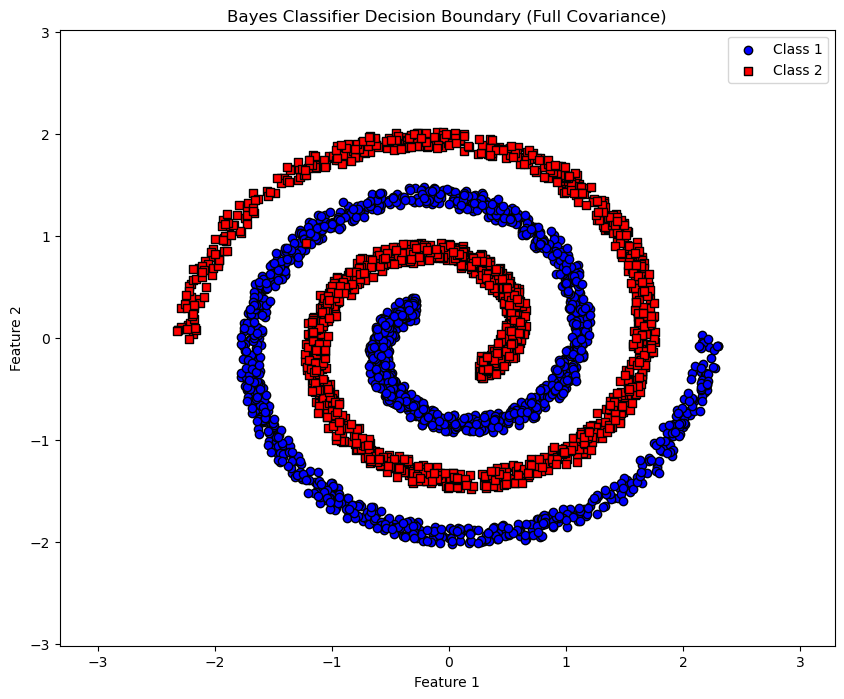

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the files, skipping the header row
class1_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class1.txt')
class2_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Feature scaling (Standardization)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and full covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covariances[c] = np.cov(X_c, rowvar=False)
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Define function to calculate multivariate Gaussian PDF for full covariance
def multivariate_gaussian_pdf(x, mean, cov):
    size = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = 1.0 / (np.power((2 * np.pi), float(size) / 2) * np.sqrt(det_cov))
    x_mu = np.matrix(x - mean)
    result = np.exp(-0.5 * (x_mu * inv_cov * x_mu.T))
    return norm_const * result

# Define the Bayes classifier manually
def bayes_classifier(X, means, covariances, priors):
    y_pred = []
    for x in X:
        posteriors = []
        for c in means.keys():
            prior = np.log(priors[c])
            likelihood = np.log(multivariate_gaussian_pdf(x, means[c], covariances[c]))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(np.argmax(posteriors))
    return np.array(y_pred)

# Calculate priors based on training data
class_counts = np.bincount(y_train)
priors = {0: class_counts[0] / len(y_train), 1: class_counts[1] / len(y_train)}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, covariances, priors)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the grid
Z = bayes_classifier(grid, means, covariances, priors)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0., cmap='coolwarm')

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Bayes Classifier Decision Boundary (Full Covariance)')
plt.legend()
plt.show()
